# Prediksi Customer Churn SALES & MARKETING Dataset

## EXPLORATORY DATA ANALYSIS

In [2]:
# 1. import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Mengabaikan warnings agar notebook tetap rapi
warnings.filterwarnings('ignore')

# Set style untuk visualisasi seaborn agar tampilannya lebih profesional
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [3]:
# 2. loading dataset CSV

file_path = 'Sales - Marketing customer dataset.csv'
df = pd.read_csv(file_path)

# Memastikan data telah termuat dengan menampilkan jumlah baris dan kolom
print(f"Dataset berhasil dimuat!")
print(f"Total baris: {df.shape[0]}")
print(f"Total kolom: {df.shape[1]}")


Dataset berhasil dimuat!
Total baris: 15000
Total kolom: 30


In [4]:
# 3. menampilkan 5 baris pertama

df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [5]:
# 4. Menampilkan informasi struktur dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [6]:
# 5. menampilkan statistik deskriptif dataset

df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [7]:
# 6. Menghitung persentase nilai kosong (missing value) pada setiap kolom

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Membuat DataFrame untuk menampilkan kolom yang memiliki missing value saja
missing_df = pd.DataFrame({
    'Total Missing': missing_values, 
    'Percentage (%)': missing_percentage
})
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("Kolom dengan Missing Values:")
missing_df


Kolom dengan Missing Values:


,Total Missing,Percentage (%)
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000


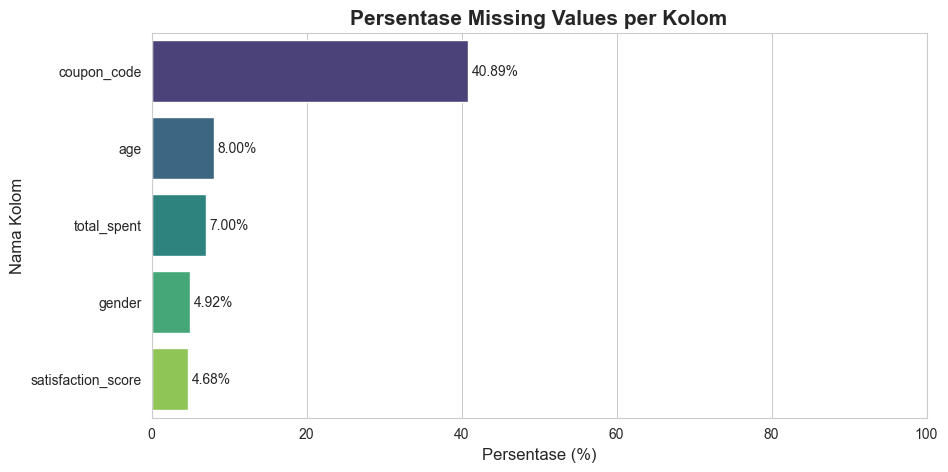

In [8]:
# 7. Membuat visualisasi diagram batang untuk persentase missing value

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df['Percentage (%)'], y=missing_df.index, palette='viridis')

plt.title('Persentase Missing Values per Kolom', fontsize=15, fontweight='bold')
plt.xlabel('Persentase (%)', fontsize=12)
plt.ylabel('Nama Kolom', fontsize=12)
plt.xlim(0, 100) # Batas sumbu X hingga 100%

# Menambahkan teks angka persentase di ujung batang
for index, value in enumerate(missing_df['Percentage (%)']):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center', fontsize=10)

plt.show()

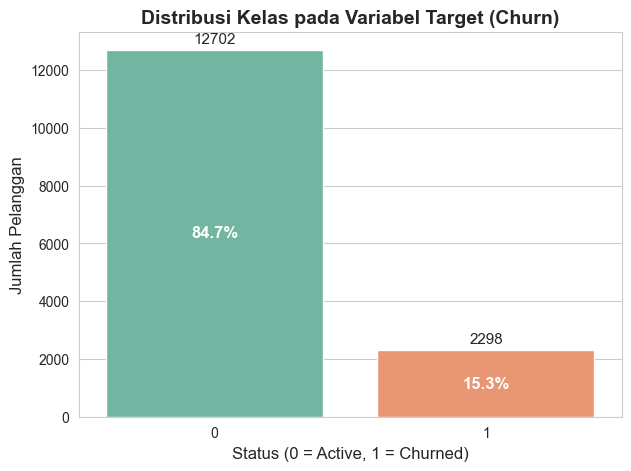

In [9]:
# 8. Membuat visualisasi diagram batang distribusi variabel target (churn)

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='churn', data=df, palette='Set2')

plt.title('Distribusi Kelas pada Variabel Target (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)

# Menambahkan teks jumlah data di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=11)

# Menambahkan persentase proporsi kelas
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                ha='center', va='center', 
                color='white', fontweight='bold', fontsize=12)

plt.show()

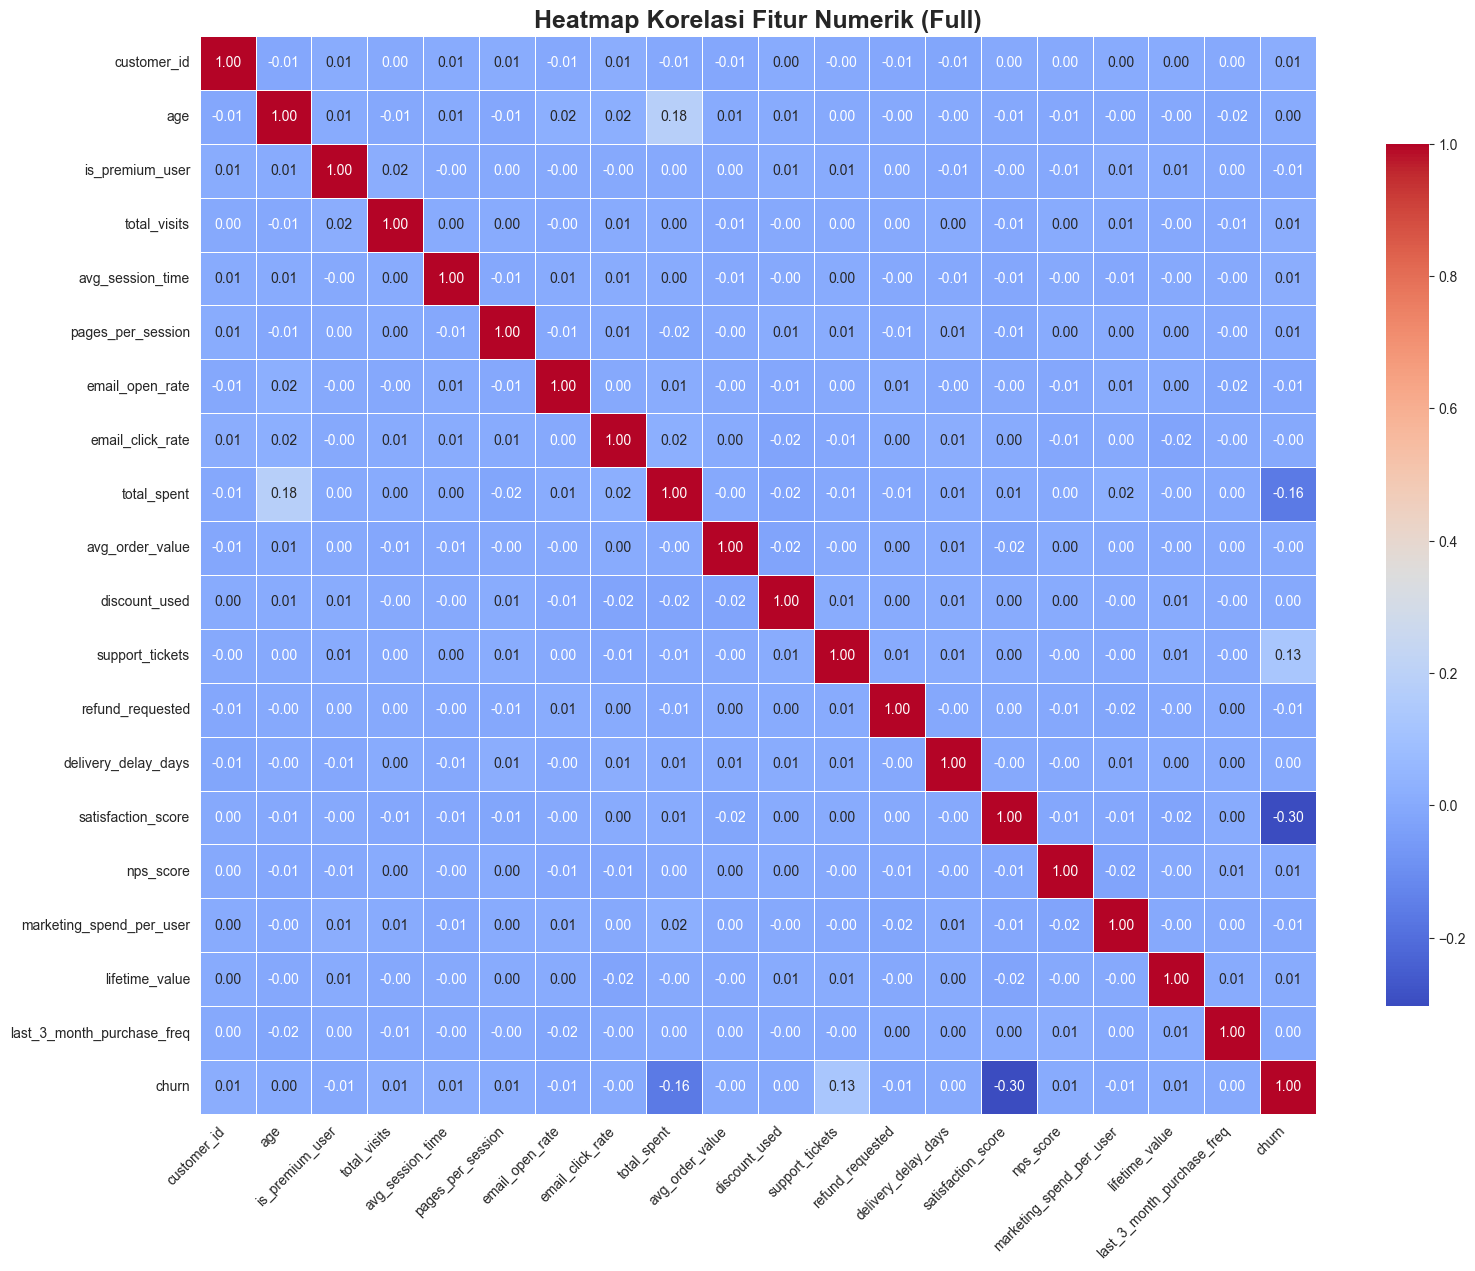

In [10]:
# 9. Membuat visualisasi heatmap korelasi khusus untuk fitur numerik secara penuh (full box)

# Memilih hanya kolom-kolom bertipe data numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df[numeric_cols]

# Menghitung matriks korelasi Pearson
correlation_matrix = df_numeric.corr()

# Membuat Heatmap tanpa mask
plt.figure(figsize=(18, 14)) 

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Heatmap Korelasi Fitur Numerik (Full)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.show()


## DIRECT MODELLING

In [11]:
# 10. Import library Machine Learning

# Library untuk pemisahan data dan metrik evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Library untuk Model Machine Learning (Sesuai instruksi: Konvensional, Bagging, Voting)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

print("Library Machine Learning berhasil di-import!")


Library Machine Learning berhasil di-import!


In [12]:
# 11. Menyiapkan dataset sementara untuk Direct Modeling

# Mengambil fitur numerik saja dan menghapus baris yang mengandung NaN
# secara paksa tanpa teknik imputasi (karena dilarang melakukan preprocessing di tahap ini)
df_direct = df.select_dtypes(include=['int64', 'float64']).dropna()

print(f"Dimensi data awal       : {df.shape}")
print(f"Dimensi data direct mentah: {df_direct.shape}")


Dimensi data awal       : (15000, 30)
Dimensi data direct mentah: (12246, 20)


In [13]:
# 12. Menetapkan fitur prediktor (X) dan variabel target (y)

# Target variabel adalah 'churn'
y_direct = df_direct['churn']

# Fitur prediktor adalah semua kolom numerik KECUALI 'churn'
# Kita juga membuang 'customer_id' karena ID unik tidak punya nilai prediktif (hanya label baris)
X_direct = df_direct.drop(columns=['churn', 'customer_id'])

print("Fitur Prediktor (X) dan Target (y) berhasil ditetapkan!")
print(f"Bentuk X: {X_direct.shape}")
print(f"Bentuk y: {y_direct.shape}")


Fitur Prediktor (X) dan Target (y) berhasil ditetapkan!
Bentuk X: (12246, 18)
Bentuk y: (12246,)


In [14]:
# 13. Melakukan train-test split (data latih dan data uji)

# Proporsi yang kita gunakan adalah 80% Train : 20% Test
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_direct
)

print("Data berhasil di-split!")
print(f"Jumlah data latih (Train): {X_train_dir.shape[0]} baris")
print(f"Jumlah data uji (Test)   : {X_test_dir.shape[0]} baris")

Data berhasil di-split!
Jumlah data latih (Train): 9796 baris
Jumlah data uji (Test)   : 2450 baris


In [15]:
# 14. Inisiasi 3 Model Machine Learning (Sesuai Syarat Soal UAS)

# 1. Model Konvensional: Decision Tree
# random_state=42 digunakan agar hasil latih selalu konsisten/sama meski di-run berkali-kali
model_dt = DecisionTreeClassifier(random_state=42)

# 2. Model Ensemble Bagging: Random Forest
model_rf = RandomForestClassifier(random_state=42)

# 3. Model Ensemble Voting (Gabungan beberapa model konvensional)
# Kita kombinasikan Logistic Regression, KNN, dan Decision Tree
clf1 = LogisticRegression(random_state=42, max_iter=1000)
clf2 = KNeighborsClassifier()
clf3 = DecisionTreeClassifier(random_state=42)

# voting='hard' berarti hasil akhir ditentukan dari suara terbanyak/mayoritas model
model_voting = VotingClassifier(
    estimators=[('lr', clf1), ('knn', clf2), ('dt', clf3)],
    voting='hard'
)

print("Ketiga model (Decision Tree, Random Forest, Voting) berhasil diinisiasi!")


Ketiga model (Decision Tree, Random Forest, Voting) berhasil diinisiasi!


In [16]:
# 15. Melatih (Training) Model Konvensional - Decision Tree

# Fungsi .fit() akan membuat model mempelajari pola hubungan antara X (prediktor) dan y (target)
model_dt.fit(X_train_dir, y_train_dir)

print("Model Decision Tree selesai dilatih!")


Model Decision Tree selesai dilatih!


In [17]:
# 16. Melatih (Training) Model Ensemble Bagging - Random Forest

# Melatih Random Forest (yang berisi banyak Decision Tree di dalamnya)
model_rf.fit(X_train_dir, y_train_dir)

print("Model Random Forest selesai dilatih!")


Model Random Forest selesai dilatih!


In [18]:
# 17. Melatih (Training) Model Ensemble Voting

# Melatih Voting Classifier (yang secara otomatis melatih LR, KNN, dan DT secara internal)
model_voting.fit(X_train_dir, y_train_dir)

print("Model Voting Classifier selesai dilatih!")


Model Voting Classifier selesai dilatih!


=== Evaluasi Decision Tree (Direct Modeling) ===
Accuracy  : 0.8322
Precision : 0.4725
Recall    : 0.4859
F1-Score  : 0.4791

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2061
           1       0.47      0.49      0.48       389

    accuracy                           0.83      2450
   macro avg       0.69      0.69      0.69      2450
weighted avg       0.83      0.83      0.83      2450



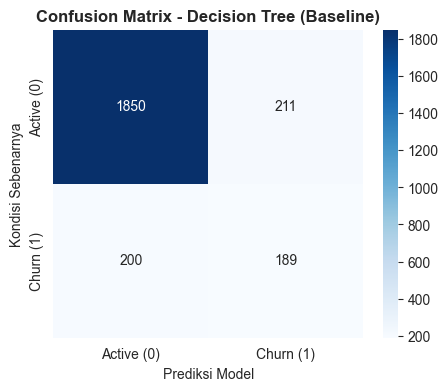

In [19]:
# 18. Evaluasi Model Konvensional (Decision Tree)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Tebakan Statis Data Uji
y_pred_dt = model_dt.predict(X_test_dir)

# Menampilkan metrik evaluasi murni
print("=== Evaluasi Decision Tree (Direct Modeling) ===")
print(f"Accuracy  : {accuracy_score(y_test_dir, y_pred_dt):.4f}")
print(f"Precision : {precision_score(y_test_dir, y_pred_dt):.4f}")
print(f"Recall    : {recall_score(y_test_dir, y_pred_dt):.4f}")
print(f"F1-Score  : {f1_score(y_test_dir, y_pred_dt):.4f}\n")

# Menampilkan detail Classification Report
print("Classification Report:")
print(classification_report(y_test_dir, y_pred_dt))

# Membuat visualisasi Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test_dir, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Decision Tree (Baseline)', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


=== Evaluasi Random Forest (Direct Modeling) ===
Accuracy  : 0.8376
Precision : 0.4863
Recall    : 0.4113
F1-Score  : 0.4457



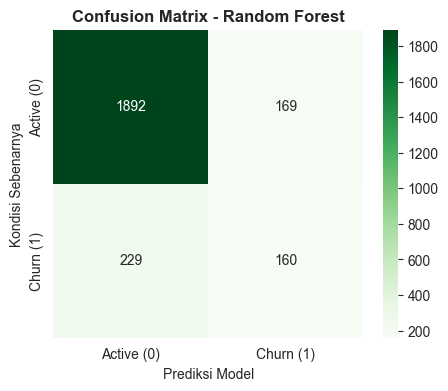

In [20]:
# 19. Evaluasi Model Ensemble Bagging (Random Forest)

y_pred_rf = model_rf.predict(X_test_dir)

print("=== Evaluasi Random Forest (Direct Modeling) ===")
print(f"Accuracy  : {accuracy_score(y_test_dir, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test_dir, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test_dir, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test_dir, y_pred_rf):.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_dir, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Random Forest', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


=== Evaluasi Voting Classifier (Direct Modeling) ===
Accuracy  : 0.8367
Precision : 0.4631
Recall    : 0.1774
F1-Score  : 0.2565



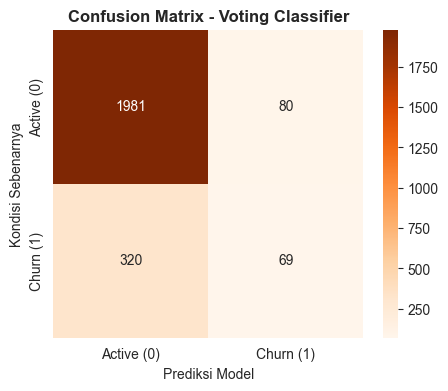

In [21]:
# 20. Evaluasi Model Ensemble Voting

y_pred_voting = model_voting.predict(X_test_dir)

print("=== Evaluasi Voting Classifier (Direct Modeling) ===")
print(f"Accuracy  : {accuracy_score(y_test_dir, y_pred_voting):.4f}")
print(f"Precision : {precision_score(y_test_dir, y_pred_voting):.4f}")
print(f"Recall    : {recall_score(y_test_dir, y_pred_voting):.4f}")
print(f"F1-Score  : {f1_score(y_test_dir, y_pred_voting):.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_dir, y_pred_voting), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Voting Classifier', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


In [22]:
# 21. Perbandingan Performa 3 Model (Direct Modeling)

import pandas as pd

# Mengumpulkan metrik murni (tanpa Cross Validation)
eval_data = {
    'Model': ['Decision Tree', 'Random Forest', 'Voting Classifier'],
    'Accuracy': [
        accuracy_score(y_test_dir, y_pred_dt),
        accuracy_score(y_test_dir, y_pred_rf),
        accuracy_score(y_test_dir, y_pred_voting)
    ],
    'Precision': [
        precision_score(y_test_dir, y_pred_dt),
        precision_score(y_test_dir, y_pred_rf),
        precision_score(y_test_dir, y_pred_voting)
    ],
    'Recall': [
        recall_score(y_test_dir, y_pred_dt),
        recall_score(y_test_dir, y_pred_rf),
        recall_score(y_test_dir, y_pred_voting)
    ],
    'F1-Score': [
        f1_score(y_test_dir, y_pred_dt),
        f1_score(y_test_dir, y_pred_rf),
        f1_score(y_test_dir, y_pred_voting)
    ]
}

# Membuat DataFrame dari dictionary
df_eval = pd.DataFrame(eval_data)
df_eval.set_index('Model', inplace=True)

print("=== Tabel Perbandingan Model (Baseline / Direct Modeling) ===")
display(df_eval)


=== Tabel Perbandingan Model (Baseline / Direct Modeling) ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.832245,0.472500,0.485861,0.479087
Random Forest,0.837551,0.486322,0.411311,0.445682
Voting Classifier,0.836735,0.463087,0.177378,0.256506


## DATA PREPROCESSING

In [23]:
# 22. Mengecek dan menghapus baris duplikat

print(f"Jumlah baris sebelum cek duplikat: {df.shape[0]}")

# Menghitung jumlah baris yang identik/sama persis
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat yang ditemukan: {jumlah_duplikat}")

# Menghapus duplikat (menyisakan 1 baris asli untuk setiap data yang ganda)
if jumlah_duplikat > 0:
    df = df.drop_duplicates(keep='first')
    
print(f"Jumlah baris setelah hapus duplikat: {df.shape[0]}")

Jumlah baris sebelum cek duplikat: 15000
Jumlah baris duplikat yang ditemukan: 0
Jumlah baris setelah hapus duplikat: 15000


In [24]:
# 23. Ekstraksi fitur Datetime (Feature Engineering)

# Mengubah format teks menjadi tipe data Datetime (Waktu) sesungguhnya
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# Kita tetapkan "Hari Ini" sebagai tanggal paling akhir dari seluruh transaksi di dataset
# Ini penting agar perhitungannya realistis terhadap usia dataset
current_date = df['last_purchase_date'].max()

# Membuat fitur "Tenure": Selisih hari antara "Hari Ini" dengan tanggal daftar
df['days_since_signup'] = (current_date - df['signup_date']).dt.days

# Membuat fitur "Recency": Selisih hari antara "Hari Ini" dengan pembelian terakhir
df['days_since_last_purchase'] = (current_date - df['last_purchase_date']).dt.days

print("✅ Ekstraksi fitur Datetime (Tenure & Recency) berhasil dilakukan!")


✅ Ekstraksi fitur Datetime (Tenure & Recency) berhasil dilakukan!


In [25]:
# 24. Membuang kolom yang tidak relevan

# Daftar kolom yang akan dibuang
kolom_sampah = ['customer_id', 'signup_date', 'last_purchase_date']

# Menghapus kolom dari dataset
df.drop(columns=kolom_sampah, inplace=True)

print("✅ Kolom 'customer_id' dan kolom tanggal asli berhasil dihapus!")
print(f"Total sisa kolom untuk model: {df.shape[1]}")


✅ Kolom 'customer_id' dan kolom tanggal asli berhasil dihapus!
Total sisa kolom untuk model: 29


In [26]:
# 25. Menetapkan X dan y, lalu membelah data (Train-Test Split)

# Memisahkan target (y) dan fitur prediktor (X)
y = df['churn']
X = df.drop(columns=['churn'])

# Membelah data (80% Train, 20% Test)
# Wajib menggunakan stratify=y untuk mengawal porsi imbalanced class (85:15)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("✅ Data berhasil diamankan dan dibelah!")
print(f"Porsi Latih (X_train) : {X_train.shape[0]} baris")
print(f"Porsi Uji (X_test)    : {X_test.shape[0]} baris")


✅ Data berhasil diamankan dan dibelah!
Porsi Latih (X_train) : 12000 baris
Porsi Uji (X_test)    : 3000 baris


In [27]:
# 26. Penanganan Missing Values Numerik (Mencegah Data Leakage)

# Daftar kolom numerik yang memiliki nilai kosong
num_cols_with_na = ['age', 'total_spent', 'satisfaction_score']

# PERHATIAN: Kalkulasi statistik HANYA boleh bersumber dari X_train
for col in num_cols_with_na:
    median_val = X_train[col].median() # Tahap FIT (Belajar dari Train)
    
    # Tahap TRANSFORM (Menerapkan ke Train dan Test)
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

print("✅ Missing values numerik diisi dengan aman tanpa Data Leakage!")
print("\nSisa missing values numerik di X_train:")
print(X_train[num_cols_with_na].isnull().sum())
print("\nSisa missing values numerik di X_test:")
print(X_test[num_cols_with_na].isnull().sum())


✅ Missing values numerik diisi dengan aman tanpa Data Leakage!

Sisa missing values numerik di X_train:
age                   0
total_spent           0
satisfaction_score    0
dtype: int64

Sisa missing values numerik di X_test:
age                   0
total_spent           0
satisfaction_score    0
dtype: int64


In [28]:
# 27. Penanganan Missing Values Kategorikal

# 1. Menangani kolom 'gender' dengan Modus dari X_train (mencegah leakage)
gender_mode = X_train['gender'].mode()[0] # FIT
X_train['gender'].fillna(gender_mode, inplace=True) # TRANSFORM ke Train
X_test['gender'].fillna(gender_mode, inplace=True)  # TRANSFORM ke Test

# 2. Menangani kolom 'coupon_code' dengan string statis
# Karena tidak menggunakan perhitungan statistik dari data, ini aman diterapkan langsung
X_train['coupon_code'].fillna('No Coupon', inplace=True)
X_test['coupon_code'].fillna('No Coupon', inplace=True)

print("✅ Missing values pada kolom kategorikal berhasil ditangani!")
print("\nTotal sisa sel kosong (NaN) di seluruh data:")
print("Di X_train:", X_train.isnull().sum().sum())
print("Di X_test :", X_test.isnull().sum().sum())


✅ Missing values pada kolom kategorikal berhasil ditangani!

Total sisa sel kosong (NaN) di seluruh data:
Di X_train: 0
Di X_test : 0


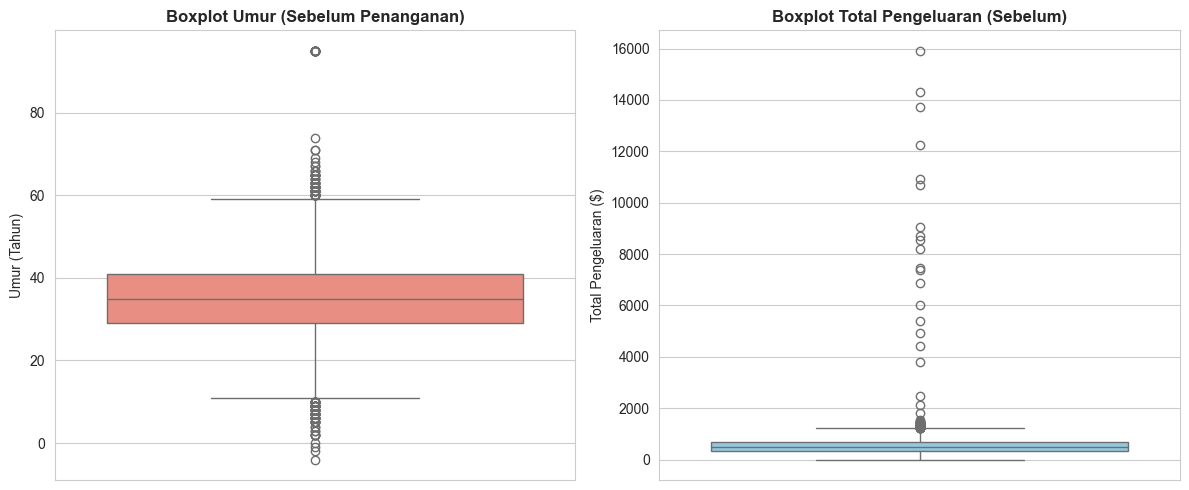

In [29]:
# 28. Visualisasi Outlier (SEBELUM ditangani)

plt.figure(figsize=(12, 5))

# Boxplot untuk mendeteksi anomali pada Umur (age)
plt.subplot(1, 2, 1)
sns.boxplot(y=X_train['age'], color='salmon')
plt.title('Boxplot Umur (Sebelum Penanganan)', fontweight='bold')
plt.ylabel('Umur (Tahun)')

# Boxplot untuk mendeteksi anomali pada Pengeluaran (total_spent)
plt.subplot(1, 2, 2)
sns.boxplot(y=X_train['total_spent'], color='skyblue')
plt.title('Boxplot Total Pengeluaran (Sebelum)', fontweight='bold')
plt.ylabel('Total Pengeluaran ($)')

plt.tight_layout()
plt.show()


In [30]:
# 29. Penanganan Outlier (Metode Clipping / Capping)

# 1. Menangani Umur (age): 
# Secara logika bisnis, umur tidak mungkin minus. Kita batasi (clip) umur ke rentang logis 17 hingga 80 tahun.
X_train['age'] = X_train['age'].clip(lower=17, upper=70)
X_test['age']  = X_test['age'].clip(lower=17, upper=70)

# 2. Menangani Total Pengeluaran (total_spent) dengan teknik IQR (Interquartile Range)
Q1 = X_train['total_spent'].quantile(0.25)
Q3 = X_train['total_spent'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = max(0, Q1 - 1.5 * IQR) # Minimum 0 karena pengeluaran tak mungkin negatif
batas_atas = Q3 + 1.5 * IQR

# Semua nilai ekstrem yang melebihi batas_atas akan "dipangkas" nilainya menjadi sebatas batas_atas
X_train['total_spent'] = X_train['total_spent'].clip(lower=batas_bawah, upper=batas_atas)
X_test['total_spent']  = X_test['total_spent'].clip(lower=batas_bawah, upper=batas_atas)

print("✅ Outlier pada 'age' dan 'total_spent' berhasil dipangkas (clipped) ke batas yang wajar!")


✅ Outlier pada 'age' dan 'total_spent' berhasil dipangkas (clipped) ke batas yang wajar!


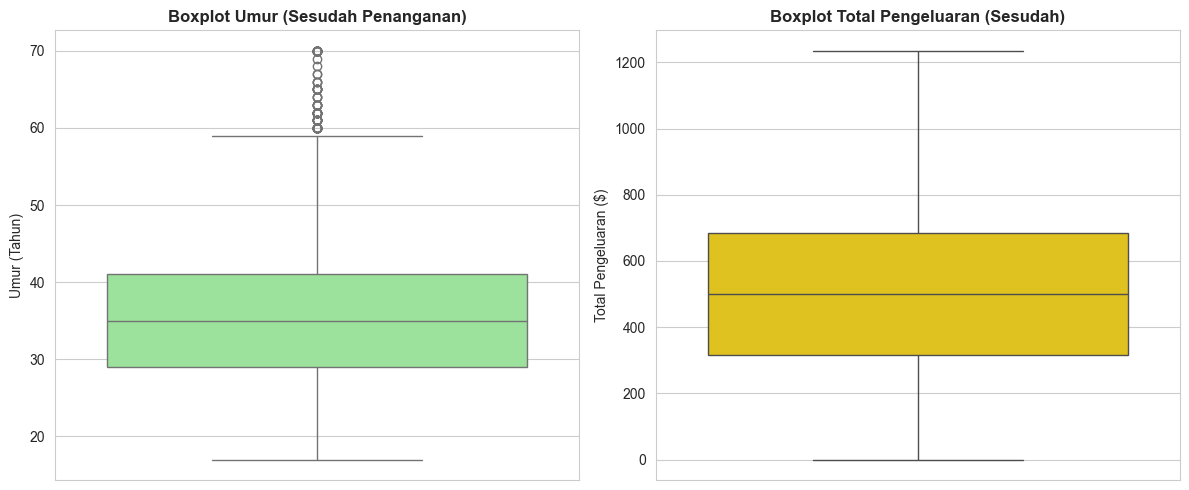

In [31]:
# 30. Visualisasi Outlier (SESUDAH ditangani)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=X_train['age'], color='lightgreen')
plt.title('Boxplot Umur (Sesudah Penanganan)', fontweight='bold')
plt.ylabel('Umur (Tahun)')

plt.subplot(1, 2, 2)
sns.boxplot(y=X_train['total_spent'], color='gold')
plt.title('Boxplot Total Pengeluaran (Sesudah)', fontweight='bold')
plt.ylabel('Total Pengeluaran ($)')

plt.tight_layout()
plt.show()


In [32]:
# 31. Encoding Kategorikal (Hybrid: Label Encoding & One-Hot Encoding)

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# 1. Identifikasi Kolom Ordinal (Memiliki Hierarki)
# Kita pertahankan Label Encoding khusus untuk subscription_type
ord_cols = ['subscription_type'] 

# 2. Identifikasi Kolom Nominal (Setara) secara otomatis
# Kolom object yang bukan bertipe ordinal akan diproses dengan One-Hot Encoding
nom_cols = [col for col in X_train.select_dtypes(include=['object']).columns if col not in ord_cols]

# Dictionary untuk menyimpan LabelEncoder (Ordinal)
label_encoders = {}

# --- PROSES 1: LABEL ENCODING (Khusus Kolom Ordinal) ---
for col in ord_cols:
    le = LabelEncoder()
    # Belajar kamus HANYA dari X_train
    X_train[col] = le.fit_transform(X_train[col])
    
    # Menerjemahkan X_test menggunakan kamus X_train
    try:
        X_test[col] = le.transform(X_test[col])
    except ValueError:
        test_classes = X_test[col].unique()
        for new_class in test_classes:
            if new_class not in le.classes_:
                le.classes_ = np.append(le.classes_, new_class)
        X_test[col] = le.transform(X_test[col])
        
    label_encoders[col] = le

# --- PROSES 2: ONE-HOT ENCODING (Khusus Kolom Nominal) ---
# handle_unknown='ignore': Sangat krusial agar web Streamlit nanti tidak crash jika user menginput kategori baru
# sparse_output=False: Menghasilkan matriks dense (array NumPy biasa) agar bisa langsung dibalut DataFrame
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Model OHE belajar HANYA dari X_train
ohe.fit(X_train[nom_cols])

# Menerjemahkan data nominal dan mengubahnya menjadi DataFrame Pandas dengan indeks yang utuh
X_train_nom = pd.DataFrame(
    ohe.transform(X_train[nom_cols]), 
    columns=ohe.get_feature_names_out(nom_cols), 
    index=X_train.index
)
X_test_nom = pd.DataFrame(
    ohe.transform(X_test[nom_cols]), 
    columns=ohe.get_feature_names_out(nom_cols), 
    index=X_test.index
)

# --- RE-ASSEMBLE PUZZLE ---
# Buang kolom nominal mentah yang lama, lalu gabungkan dengan dummy DataFrame yang baru secara horizontal
X_train = pd.concat([X_train.drop(columns=nom_cols), X_train_nom], axis=1)
X_test = pd.concat([X_test.drop(columns=nom_cols), X_test_nom], axis=1)

print("✅ Hybrid Encoding Selesai Secara Sempurna!")
print(f"Kolom Ordinal (Label Encoded)      : {ord_cols}")
print(f"Kolom Nominal (One-Hot Encoded)    : {nom_cols}")
print(f"\nJumlah total kolom berkembang menjadi: {X_train.shape[1]} kolom (karena ekspansi OHE).")
print("\nCuplikan 5 baris pertama X_train setelah Hybrid Encoding:")
display(X_train.head())


✅ Hybrid Encoding Selesai Secara Sempurna!
Kolom Ordinal (Label Encoded)      : ['subscription_type']
Kolom Nominal (One-Hot Encoded)    : ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'coupon_code', 'payment_method']

Jumlah total kolom berkembang menjadi: 53 kolom (karena ekspansi OHE).

Cuplikan 5 baris pertama X_train setelah Hybrid Encoding:


,age,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,...,device_type_Tablet,coupon_code_NEW20,coupon_code_No Coupon,coupon_code_REF10,coupon_code_SALE15,payment_method_BKash,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
8722,34.0,1,0,8,9.995857,2.290988,0.99,0.42,286.240397,78.212926,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12778,35.0,1,1,14,8.383313,5.248471,0.85,0.05,194.005765,55.837077,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
11229,34.0,1,0,11,9.113516,2.962681,0.35,0.25,336.153441,59.682320,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4671,42.0,0,0,11,6.954997,3.924745,0.01,0.44,612.087140,47.276339,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4247,41.0,0,0,13,7.003106,2.351749,0.50,0.00,494.769945,70.239036,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [33]:
# 32. Feature Scaling (Penyetaraan Skala)

from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Inisiasi Scaler
scaler = StandardScaler()

# Menyimpan daftar nama kolom agar format DataFrame tidak hilang
kolom_X = X_train.columns

# 2. Tahap FIT & TRANSFORM: Scaler mempelajari rata-rata & varians dari X_train, lalu menskalakannya
X_train_scaled = scaler.fit_transform(X_train)

# 3. Tahap TRANSFORM: Menskalakan X_test menggunakan parameter yang dipelajari dari X_train
X_test_scaled = scaler.transform(X_test)

# (Opsional tapi direkomendasikan): Mengembalikan format dari Numpy Array menjadi Pandas DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=kolom_X)
X_test = pd.DataFrame(X_test_scaled, columns=kolom_X)

print("✅ Feature Scaling (StandardScaler) berhasil dilakukan secara aman!")
print("\nCuplikan data X_train setelah di-scale (sekarang semuanya diukur dalam standar deviasi yang setara):")
display(X_train.head())


✅ Feature Scaling (StandardScaler) berhasil dilakukan secara aman!

Cuplikan data X_train setelah di-scale (sekarang semuanya diukur dalam standar deviasi yang setara):


,age,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,...,device_type_Tablet,coupon_code_NEW20,coupon_code_No Coupon,coupon_code_REF10,coupon_code_SALE15,payment_method_BKash,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,-0.141907,0.977911,-0.670541,-1.800890,0.658691,-1.160708,1.699394,1.166088,-0.834394,0.742849,...,1.397410,-0.486681,1.202698,-0.499479,-0.500130,-0.500521,-0.489953,1.997919,-0.501302,-0.507671
1,-0.035009,0.977911,1.491333,-0.257490,0.119994,0.829867,1.216860,-1.390087,-1.178064,-0.161298,...,1.397410,-0.486681,-0.831464,2.002086,-0.500130,-0.500521,2.041013,-0.500521,-0.501302,-0.507671
2,-0.141907,0.977911,-0.670541,-1.029190,0.363930,-0.708615,-0.506473,-0.008371,-0.648417,-0.005922,...,-0.715609,-0.486681,-0.831464,-0.499479,1.999479,-0.500521,-0.489953,1.997919,-0.501302,-0.507671
3,0.713276,-1.022588,-0.670541,-1.029190,-0.357159,-0.061085,-1.678340,1.304259,0.379721,-0.507214,...,-0.715609,-0.486681,-0.831464,-0.499479,1.999479,-0.500521,-0.489953,-0.500521,-0.501302,1.969780
4,0.606379,-1.022588,-0.670541,-0.514724,-0.341088,-1.119811,0.010527,-1.735516,-0.057407,0.420646,...,-0.715609,-0.486681,1.202698,-0.499479,-0.500130,-0.500521,2.041013,-0.500521,-0.501302,-0.507671


=== Kondisi Awal (Imbalanced) ===
Total baris X_train : 12000
churn
0    10162
1     1838
Name: count, dtype: int64


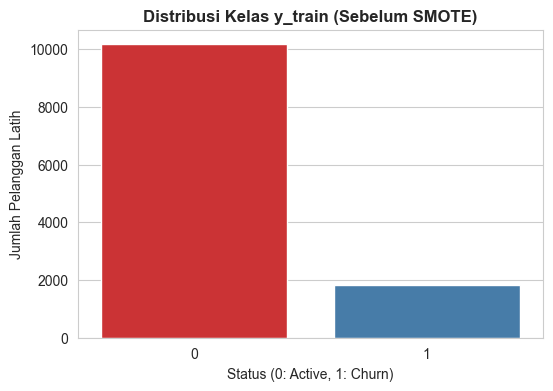

In [34]:
# 33. Visualisasi Kelas SEBELUM SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

print("=== Kondisi Awal (Imbalanced) ===")
print(f"Total baris X_train : {X_train.shape[0]}")
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette='Set1', legend=False)
plt.title('Distribusi Kelas y_train (Sebelum SMOTE)', fontweight='bold')
plt.xlabel('Status (0: Active, 1: Churn)')
plt.ylabel('Jumlah Pelanggan Latih')
plt.show()


In [35]:
# 34. Penerapan SMOTETomek (Hybrid Oversampling & Undersampling)

from imblearn.combine import SMOTETomek

print("Menyeimbangkan kelas dan membersihkan perbatasan dengan SMOTETomek...")

# Inisiasi SMOTETomek
# random_state=42 dikunci agar proses acak pembuatan data sintetik selalu identik setiap kali di-run
smt = SMOTETomek(random_state=42)

# Tahap FIT & RESAMPLE: SMOTE beraksi mencetak data minoritas, Tomek Links memotong overlap perbatasan
X_train, y_train = smt.fit_resample(X_train, y_train)

print("\n✅ Eksekusi SMOTETomek Selesai!")
print("Data latih Anda kini seimbang sempurna dan perbatasannya telah dibersihkan secara kejam dari noise!")


Menyeimbangkan kelas dan membersihkan perbatasan dengan SMOTETomek...

✅ Eksekusi SMOTETomek Selesai!
Data latih Anda kini seimbang sempurna dan perbatasannya telah dibersihkan secara kejam dari noise!


=== Kondisi Baru (Balanced 50:50) ===
Total baris X_train : 20322
churn
1    10161
0    10161
Name: count, dtype: int64


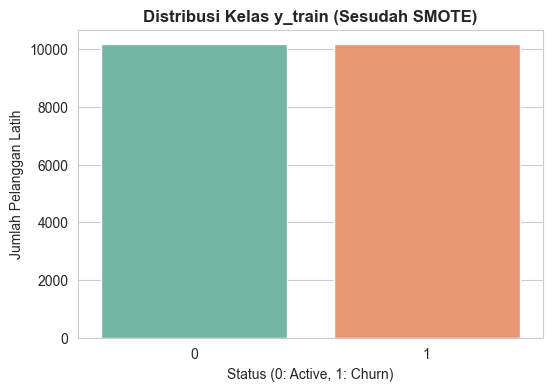

In [36]:
# 35. Visualisasi Kelas SESUDAH SMOTE

print("=== Kondisi Baru (Balanced 50:50) ===")
print(f"Total baris X_train : {X_train.shape[0]}")
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette='Set2', legend=False)
plt.title('Distribusi Kelas y_train (Sesudah SMOTE)', fontweight='bold')
plt.xlabel('Status (0: Active, 1: Churn)')
plt.ylabel('Jumlah Pelanggan Latih')
plt.show()


## MODELLING DENGAN PREPROCESSING

In [37]:
# 36. Inisiasi Ulang Ketiga Model (Reset Memori)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 1. Inisiasi ulang Decision Tree (Beri nama variabel baru agar tidak tertukar)
model_dt_clean = DecisionTreeClassifier(random_state=42)

# 2. Inisiasi ulang Random Forest
model_rf_clean = RandomForestClassifier(random_state=42)

# 3. Inisiasi ulang komponen pembentuk Voting Classifier
log_clf_clean = LogisticRegression(random_state=42, max_iter=1000)
knn_clf_clean = KNeighborsClassifier()
dt_clf_clean = DecisionTreeClassifier(random_state=42)

model_voting_clean = VotingClassifier(
    estimators=[
        ('lr', log_clf_clean), 
        ('knn', knn_clf_clean), 
        ('dt', dt_clf_clean)
    ],
    voting='hard'
)

print("✅ Memori model di-reset. Ketiga model berstatus bersih dan siap dilatih!")


✅ Memori model di-reset. Ketiga model berstatus bersih dan siap dilatih!


In [38]:
# 37. Melatih (Training) Decision Tree pada data preprocessed

# Menyuntikkan data bersih (X_train dan y_train) ke dalam model
model_dt_clean.fit(X_train, y_train)

print("✅ Model Decision Tree (Clean) selesai dilatih!")

✅ Model Decision Tree (Clean) selesai dilatih!


=== Evaluasi Decision Tree (Clean Data) ===
Accuracy  : 0.8553
Precision : 0.5267
Recall    : 0.5565
F1-Score  : 0.5412



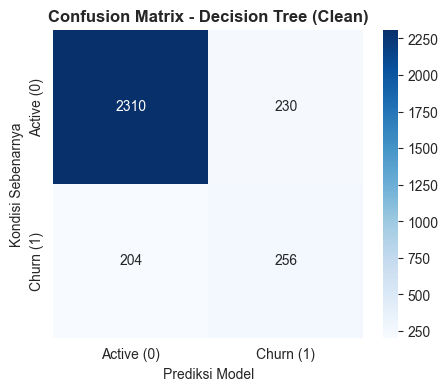

In [39]:
# 38. Evaluasi Decision Tree (Data Preprocessed)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tebakan Statis Data Uji
y_pred_dt_clean = model_dt_clean.predict(X_test)

# Menampilkan metrik evaluasi murni
print("=== Evaluasi Decision Tree (Clean Data) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dt_clean):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_dt_clean):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt_clean):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_dt_clean):.4f}\n")

# Visualisasi Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_dt_clean)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Decision Tree (Clean)', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


In [40]:
# 39. Melatih (Training) Random Forest pada data preprocessed

# Menyuntikkan data bersih (X_train dan y_train) ke dalam model
model_rf_clean.fit(X_train, y_train)

print("✅ Model Random Forest (Clean) selesai dilatih!")


✅ Model Random Forest (Clean) selesai dilatih!


=== Evaluasi Random Forest (Clean Data) ===
Accuracy  : 0.8507
Precision : 0.5118
Recall    : 0.5674
F1-Score  : 0.5381



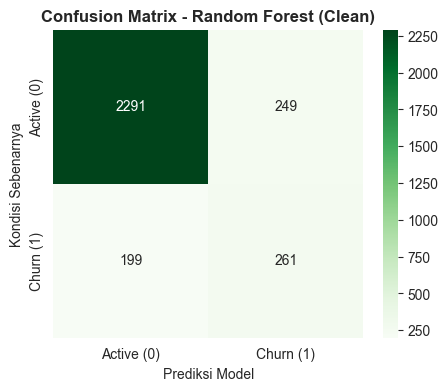

In [41]:
# 40. Evaluasi Random Forest (Data Preprocessed)

# Tebakan Statis Data Uji
y_pred_rf_clean = model_rf_clean.predict(X_test)

# Menampilkan metrik evaluasi murni
print("=== Evaluasi Random Forest (Clean Data) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf_clean):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf_clean):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf_clean):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf_clean):.4f}\n")

# Visualisasi Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_clean), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Random Forest (Clean)', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


In [42]:
# 41. Melatih (Training) Voting Classifier pada data preprocessed

# Menyuntikkan data bersih ke model gabungan ini
model_voting_clean.fit(X_train, y_train)

print("✅ Model Voting Classifier (Clean) selesai dilatih!")


✅ Model Voting Classifier (Clean) selesai dilatih!


=== Evaluasi Voting Classifier (Clean Data) ===
Accuracy  : 0.7950
Precision : 0.4030
Recall    : 0.7000
F1-Score  : 0.5115



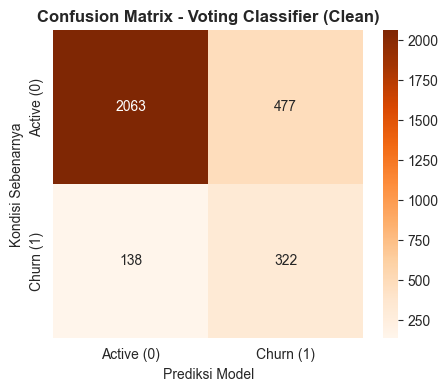

In [43]:
# 42. Evaluasi Voting Classifier (Data Preprocessed)

# Tebakan Statis Data Uji
y_pred_voting_clean = model_voting_clean.predict(X_test)

# Menampilkan metrik evaluasi murni
print("=== Evaluasi Voting Classifier (Clean Data) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_voting_clean):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_voting_clean):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_voting_clean):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_voting_clean):.4f}\n")

# Visualisasi Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_voting_clean), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Voting Classifier (Clean)', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


In [44]:
# 43. Perbandingan Performa 3 Model (Clean Data)

import pandas as pd

# Mengumpulkan metrik murni (tanpa Cross Validation)
eval_data_clean = {
    'Model': ['Decision Tree (Clean)', 'Random Forest (Clean)', 'Voting Classifier (Clean)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt_clean),
        accuracy_score(y_test, y_pred_rf_clean),
        accuracy_score(y_test, y_pred_voting_clean)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt_clean),
        precision_score(y_test, y_pred_rf_clean),
        precision_score(y_test, y_pred_voting_clean)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt_clean),
        recall_score(y_test, y_pred_rf_clean),
        recall_score(y_test, y_pred_voting_clean)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt_clean),
        f1_score(y_test, y_pred_rf_clean),
        f1_score(y_test, y_pred_voting_clean)
    ]
}

df_eval_clean = pd.DataFrame(eval_data_clean)
df_eval_clean.set_index('Model', inplace=True)

print("=== Tabel Perbandingan Model (Clean Data + SMOTETomek) ===")
display(df_eval_clean)


=== Tabel Perbandingan Model (Clean Data + SMOTETomek) ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree (Clean),0.855333,0.526749,0.556522,0.541226
Random Forest (Clean),0.850667,0.511765,0.567391,0.538144
Voting Classifier (Clean),0.795000,0.403004,0.700000,0.511517


In [45]:
# 44. Analisis Perbandingan Keseluruhan (Direct vs Preprocessed)

# Menyeragamkan nama index tabel kotor (dari Cell 21) agar saat digabung terlihat jelas
df_eval.index = ['Decision Tree (Kotor)', 'Random Forest (Kotor)', 'Voting Classifier (Kotor)']

# Menggabungkan kedua tabel menjadi satu tabel raksasa
# Karena Cell 21 dan Cell 43 sekarang sama-sama punya kolom 'F1-Score (CV Mean)', penggabungannya akan sempurna
df_komparasi_total = pd.concat([df_eval, df_eval_clean])

print("=== KOMPARASI TOTAL: DATA MENTAH VS DATA BERSIH ===")
display(df_komparasi_total.sort_index())


=== KOMPARASI TOTAL: DATA MENTAH VS DATA BERSIH ===


,Accuracy,Precision,Recall,F1-Score
Decision Tree (Clean),0.855333,0.526749,0.556522,0.541226
Decision Tree (Kotor),0.832245,0.472500,0.485861,0.479087
Random Forest (Clean),0.850667,0.511765,0.567391,0.538144
Random Forest (Kotor),0.837551,0.486322,0.411311,0.445682
Voting Classifier (Clean),0.795000,0.403004,0.700000,0.511517
Voting Classifier (Kotor),0.836735,0.463087,0.177378,0.256506


## HYPERPARAMETER RUNING

In [46]:
# 45. Melakukan Feature Importance Analysis (Base Model: Random Forest)

# 1. Mengambil skor bobot fitur langsung dari "otak" model Random Forest
rf_importances = model_rf_clean.feature_importances_

# 2. Menyatukan nama kolom (X_train.columns) dengan skornya ke dalam tabel
df_importance = pd.DataFrame({
    'Fitur': X_train.columns,
    'Skor_Kepentingan': rf_importances
})

# 3. Mengurutkan fitur dari yang skornya paling tinggi ke paling rendah
df_importance = df_importance.sort_values(by='Skor_Kepentingan', ascending=False).reset_index(drop=True)

print("✅ Analisis Feature Importance berhasil diekstraksi!")
print("=== Peringkat Kepentingan Fitur ===")
display(df_importance)


✅ Analisis Feature Importance berhasil diekstraksi!
=== Peringkat Kepentingan Fitur ===


,Fitur,Skor_Kepentingan
0,satisfaction_score,0.245582
1,total_spent,0.173627
2,support_tickets,0.072453
3,subscription_type,0.032383
4,is_premium_user,0.030889
5,discount_used,0.030542
6,delivery_delay_days,0.025711
7,nps_score,0.021282
8,last_3_month_purchase_freq,0.020853
9,marketing_spend_per_user,0.019331


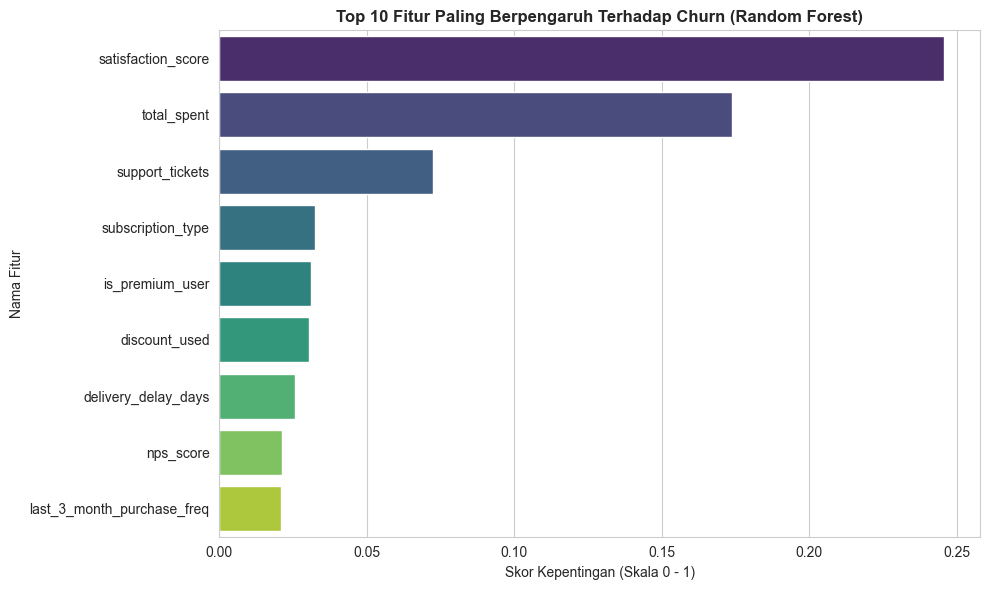

Total fitur sebelum seleksi : 53 fitur
Total fitur setelah seleksi : 20 fitur

Daftar Fitur yang Lolos Seleksi (VIP):
- satisfaction_score
- total_spent
- support_tickets
- subscription_type
- is_premium_user
- discount_used
- delivery_delay_days
- nps_score
- last_3_month_purchase_freq
- marketing_spend_per_user
- email_click_rate
- email_open_rate
- total_visits
- days_since_last_purchase
- days_since_signup
- lifetime_value
- avg_order_value
- avg_session_time
- pages_per_session
- age


In [47]:
# 46. Visualisasi Feature Importance & Feature Selection

# 1. Visualisasi Top 10 Fitur Paling Berpengaruh
plt.figure(figsize=(10, 6))
sns.barplot(x='Skor_Kepentingan', y='Fitur', data=df_importance.head(9), palette='viridis')
plt.title('Top 10 Fitur Paling Berpengaruh Terhadap Churn (Random Forest)', fontweight='bold')
plt.xlabel('Skor Kepentingan (Skala 0 - 1)')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

# 2. Tahap Feature Selection (Pembuangan Fitur Lemah)
# Kita tetapkan aturan tegas: Fitur dengan skor di bawah 1% (0.01) AKAN DIBUANG!
threshold = 0.01
fitur_terpilih = df_importance[df_importance['Skor_Kepentingan'] >= threshold]['Fitur'].tolist()

print(f"Total fitur sebelum seleksi : {len(X_train.columns)} fitur")
print(f"Total fitur setelah seleksi : {len(fitur_terpilih)} fitur")
print("\nDaftar Fitur yang Lolos Seleksi (VIP):")
for f in fitur_terpilih:
    print(f"- {f}")


In [48]:
# 47. Menyesuaikan ulang X_train dan X_test dengan Fitur Terpilih (VIP)

print(f"Dimensi X_train SEBELUM pemangkasan : {X_train.shape}")
print(f"Dimensi X_test SEBELUM pemangkasan  : {X_test.shape}")

# Hanya mengambil kolom-kolom yang ada di dalam daftar fitur_terpilih
X_train = X_train[fitur_terpilih]
X_test = X_test[fitur_terpilih]

print(f"\nDimensi X_train SESUDAH pemangkasan : {X_train.shape}")
print(f"Dimensi X_test SESUDAH pemangkasan  : {X_test.shape}")

print("\n✅ Eksekusi pemangkasan fitur selesai! Seluruh kolom 'noise' (sampah) telah resmi dibuang.")


Dimensi X_train SEBELUM pemangkasan : (20322, 53)
Dimensi X_test SEBELUM pemangkasan  : (3000, 53)

Dimensi X_train SESUDAH pemangkasan : (20322, 20)
Dimensi X_test SESUDAH pemangkasan  : (3000, 20)

✅ Eksekusi pemangkasan fitur selesai! Seluruh kolom 'noise' (sampah) telah resmi dibuang.


In [49]:
# 48. Menyusun Parameter Grid & Import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

# Parameter kombinasi untuk Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Parameter kombinasi untuk Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],            
    'bootstrap': [True, False]
}

print("✅ Ruang pencarian dan RandomizedSearchCV siap digunakan!")


✅ Ruang pencarian dan RandomizedSearchCV siap digunakan!


In [50]:
# 49. Hyperparameter Tuning untuk Decision Tree (RandomizedSearch)

print("Memulai pencarian (Max 10 Iterasi) untuk Decision Tree...")

# Inisiasi RandomizedSearchCV
random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid_dt,
    n_iter=10,        # Membatasi pencarian acak maksimal 10 kali
    cv=10,
    scoring='f1', 
    n_jobs=-1,
    random_state=42,  # Mengunci keacakan agar hasilnya bisa direproduksi
    verbose=1
)

random_search_dt.fit(X_train, y_train)
best_dt = random_search_dt.best_estimator_

print("\n✅ Pencarian Selesai!")
print("Kombinasi Parameter Terbaik:", random_search_dt.best_params_)


Memulai pencarian (Max 10 Iterasi) untuk Decision Tree...
Fitting 10 folds for each of 10 candidates, totalling 100 fits

✅ Pencarian Selesai!
Kombinasi Parameter Terbaik: {'min_samples_split': 15, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'gini'}


In [51]:
# 50. Hyperparameter Tuning untuk Random Forest (RandomizedSearch)

print("Memulai pencarian (Max 10 Iterasi) untuk Random Forest...")

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=10,
    cv=10,
    scoring='f1', 
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_train, y_train)
best_rf = random_search_rf.best_estimator_

print("\n✅ Pencarian Random Forest Selesai!")
print("Kombinasi Parameter Terbaik:", random_search_rf.best_params_)


Memulai pencarian (Max 10 Iterasi) untuk Random Forest...
Fitting 10 folds for each of 10 candidates, totalling 100 fits

✅ Pencarian Random Forest Selesai!
Kombinasi Parameter Terbaik: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 20, 'bootstrap': False}


In [52]:
# 51. Hyperparameter Tuning untuk Logistic Regression (RandomizedSearch)

print("Memulai pencarian (Max 10 Iterasi) untuk Logistic Regression...")

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

random_search_lr = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_grid_lr,
    n_iter=10,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search_lr.fit(X_train, y_train)
best_lr = random_search_lr.best_estimator_

print("✅ Pencarian Logistic Regression Selesai!")
print("Kombinasi Parameter Terbaik:", random_search_lr.best_params_)


Memulai pencarian (Max 10 Iterasi) untuk Logistic Regression...
✅ Pencarian Logistic Regression Selesai!
Kombinasi Parameter Terbaik: {'solver': 'liblinear', 'max_iter': 1000, 'C': 0.001}


In [53]:
# 52. Hyperparameter Tuning untuk K-Nearest Neighbors (RandomizedSearch)

print("Memulai pencarian (Max 10 Iterasi) untuk KNN...")

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

random_search_knn = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_grid_knn,
    n_iter=10,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search_knn.fit(X_train, y_train)
best_knn = random_search_knn.best_estimator_

print("✅ Pencarian KNN Selesai!")
print("Kombinasi Parameter Terbaik:", random_search_knn.best_params_)


Memulai pencarian (Max 10 Iterasi) untuk KNN...
✅ Pencarian KNN Selesai!
Kombinasi Parameter Terbaik: {'weights': 'distance', 'p': 1, 'n_neighbors': 3}


In [54]:
# 53. Merakit "Voting Classifier"

from sklearn.ensemble import VotingClassifier

print("Merakit dewan juri Super Voting Classifier dari model-model peraih gelar 'Best Estimator'...")

super_voting_clf = VotingClassifier(
    estimators=[
        ('lr_tuned', best_lr), 
        ('knn_tuned', best_knn), 
        ('dt_tuned', best_dt)
    ],
    voting='hard' 
)

# Melatih kembali super estimator menggunakan data latih
super_voting_clf.fit(X_train, y_train)

print("✅ Super Voting Classifier berhasil dirakit dan dilatih secara optimal!")


Merakit dewan juri Super Voting Classifier dari model-model peraih gelar 'Best Estimator'...
✅ Super Voting Classifier berhasil dirakit dan dilatih secara optimal!


=== Evaluasi BEST Decision Tree ===
Accuracy  : 0.8487
Precision : 0.5055
Recall    : 0.6043
F1-Score  : 0.5505



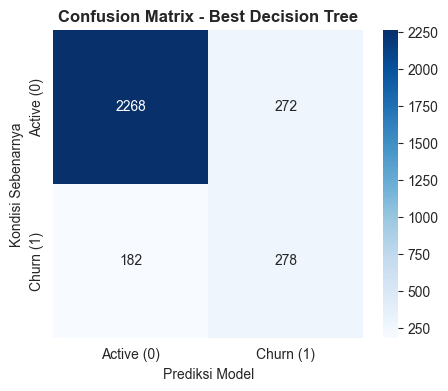

In [55]:
# 54. Evaluasi Model Decision Tree (Tuned)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_best_dt = best_dt.predict(X_test)

print("=== Evaluasi BEST Decision Tree ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best_dt):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best_dt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best_dt):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_best_dt):.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Best Decision Tree', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


=== Evaluasi BEST Random Forest ===
Accuracy  : 0.8520
Precision : 0.5148
Recall    : 0.6043
F1-Score  : 0.5560



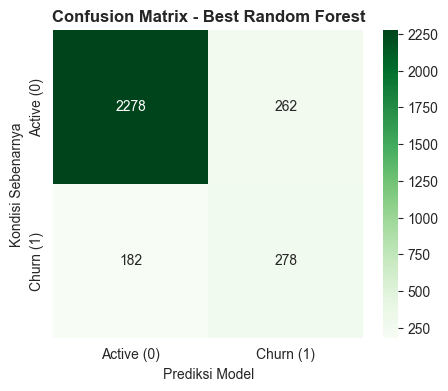

In [56]:
# 55. Evaluasi Model Random Forest (Tuned)

y_pred_best_rf = best_rf.predict(X_test)

print("=== Evaluasi BEST Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_best_rf):.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Best Random Forest', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


=== Evaluasi SUPER Voting Classifier ===
Accuracy  : 0.8157
Precision : 0.4364
Recall    : 0.6935
F1-Score  : 0.5357



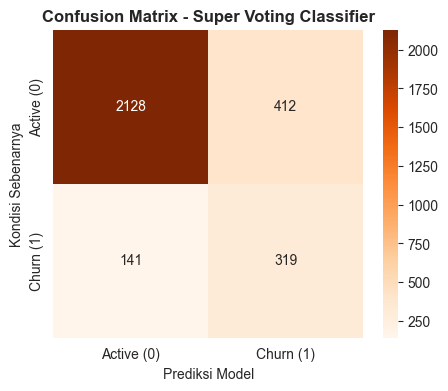

In [57]:
# 56. Evaluasi Super Voting Classifier (Tuned)

y_pred_super_vc = super_voting_clf.predict(X_test)

print("=== Evaluasi SUPER Voting Classifier ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_super_vc):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_super_vc):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_super_vc):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_super_vc):.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_super_vc), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Active (0)', 'Churn (1)'],
            yticklabels=['Active (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Super Voting Classifier', fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.show()


In [58]:
# 57. Tabel Komparasi 3 Model (Versi Tuned)

import pandas as pd

eval_tuned = {
    'Model': ['Decision Tree (Tuned)', 'Random Forest (Tuned)', 'Voting Classifier (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_best_dt),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_super_vc)
    ],
    'Precision': [
        precision_score(y_test, y_pred_best_dt),
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_super_vc)
    ],
    'Recall': [
        recall_score(y_test, y_pred_best_dt),
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_super_vc)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_best_dt),
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_super_vc)
    ]
}

df_eval_tuned = pd.DataFrame(eval_tuned)
df_eval_tuned.set_index('Model', inplace=True)

print("=== KOMPARASI 3 MODEL (VERSI TUNED) ===")
display(df_eval_tuned)


=== KOMPARASI 3 MODEL (VERSI TUNED) ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree (Tuned),0.848667,0.505455,0.604348,0.550495
Random Forest (Tuned),0.852000,0.514815,0.604348,0.556000
Voting Classifier (Tuned),0.815667,0.436389,0.693478,0.535684


=== REVISI GRAND KOMPARASI: KOTOR -> CLEAN -> TUNED ===


,Accuracy,Precision,Recall,F1-Score
Decision Tree (Kotor),0.832245,0.472500,0.485861,0.479087
Decision Tree (Clean),0.855333,0.526749,0.556522,0.541226
Decision Tree (Tuned),0.848667,0.505455,0.604348,0.550495
Random Forest (Kotor),0.837551,0.486322,0.411311,0.445682
Random Forest (Clean),0.850667,0.511765,0.567391,0.538144
Random Forest (Tuned),0.852000,0.514815,0.604348,0.556000
Voting Classifier (Kotor),0.836735,0.463087,0.177378,0.256506
Voting Classifier (Clean),0.795000,0.403004,0.700000,0.511517
Voting Classifier (Tuned),0.815667,0.436389,0.693478,0.535684


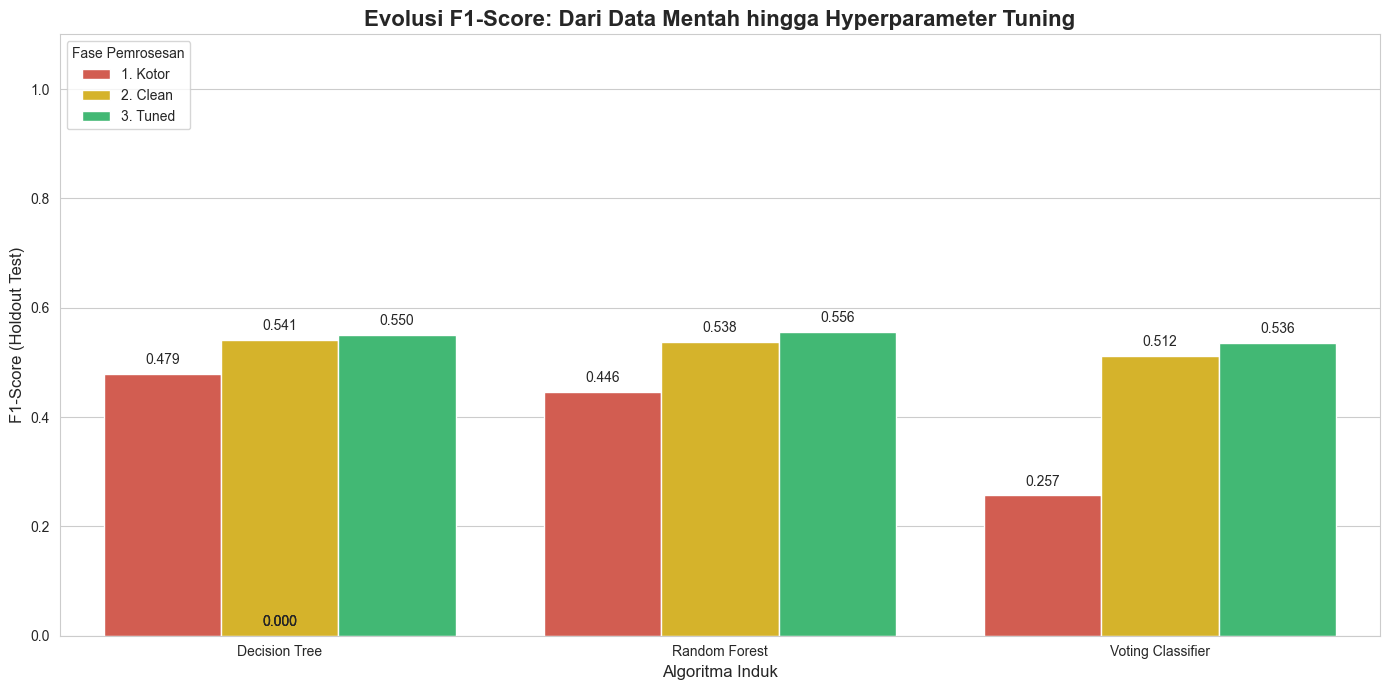

In [59]:
# 58. Grand Komparasi (Sorting Ketat & Visualisasi Grouped Bar)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Menggabungkan ketiga tabel evaluasi
df_grand_komparasi = pd.concat([df_eval, df_eval_clean, df_eval_tuned])

# Urutan kustom
urutan_kustom = [
    'Decision Tree (Kotor)', 'Decision Tree (Clean)', 'Decision Tree (Tuned)',
    'Random Forest (Kotor)', 'Random Forest (Clean)', 'Random Forest (Tuned)',
    'Voting Classifier (Kotor)', 'Voting Classifier (Clean)', 'Voting Classifier (Tuned)' 
]

# Mengubah urutan baris dataframe dan membuang baris yang tidak cocok
df_grand_komparasi = df_grand_komparasi.reindex(urutan_kustom).dropna(how='all')

print("=== REVISI GRAND KOMPARASI: KOTOR -> CLEAN -> TUNED ===")
display(df_grand_komparasi)

# --- MEMBUAT VISUALISASI ---
# Menggunakan trik ekstraksi langsung agar kebal error Pandas
data_grafik = df_grand_komparasi.copy()
data_grafik['Nama_Lengkap'] = data_grafik.index

def pisah_nama(nama):
    if 'Decision Tree' in str(nama): return 'Decision Tree'
    if 'Random Forest' in str(nama): return 'Random Forest'
    return 'Voting Classifier'

def pisah_versi(nama):
    if 'Kotor' in str(nama): return '1. Kotor'
    if 'Clean' in str(nama): return '2. Clean'
    return '3. Tuned'

data_grafik['Model_Base'] = data_grafik['Nama_Lengkap'].apply(pisah_nama)
data_grafik['Versi'] = data_grafik['Nama_Lengkap'].apply(pisah_versi)

# Menggambar Grafik (MURNI F1-SCORE)
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=data_grafik, 
    x='Model_Base', 
    y='F1-Score', # <--- REVISI: Menggunakan F1-Score biasa
    hue='Versi',
    palette=['#e74c3c', '#f1c40f', '#2ecc71'] 
)

plt.title('Evolusi F1-Score: Dari Data Mentah hingga Hyperparameter Tuning', fontweight='bold', fontsize=16)
plt.xlabel('Algoritma Induk', fontsize=12)
plt.ylabel('F1-Score (Holdout Test)', fontsize=12) # <--- REVISI Label
plt.legend(title='Fase Pemrosesan', loc='upper left')
plt.ylim(0, 1.1)

for p in ax.patches:
    tinggi = p.get_height()
    if pd.notnull(tinggi): 
        ax.annotate(f"{tinggi:.3f}", 
                    (p.get_x() + p.get_width() / 2., tinggi), 
                    ha='center', va='bottom', 
                    fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


=== KLASEMEN AKHIR (Berdasarkan F1-Score Murni) ===


,Accuracy,Precision,Recall,F1-Score
Random Forest (Tuned),0.852000,0.514815,0.604348,0.556000
Decision Tree (Tuned),0.848667,0.505455,0.604348,0.550495
Decision Tree (Clean),0.855333,0.526749,0.556522,0.541226
Random Forest (Clean),0.850667,0.511765,0.567391,0.538144
Voting Classifier (Tuned),0.815667,0.436389,0.693478,0.535684
Voting Classifier (Clean),0.795000,0.403004,0.700000,0.511517
Decision Tree (Kotor),0.832245,0.472500,0.485861,0.479087
Random Forest (Kotor),0.837551,0.486322,0.411311,0.445682
Voting Classifier (Kotor),0.836735,0.463087,0.177378,0.256506


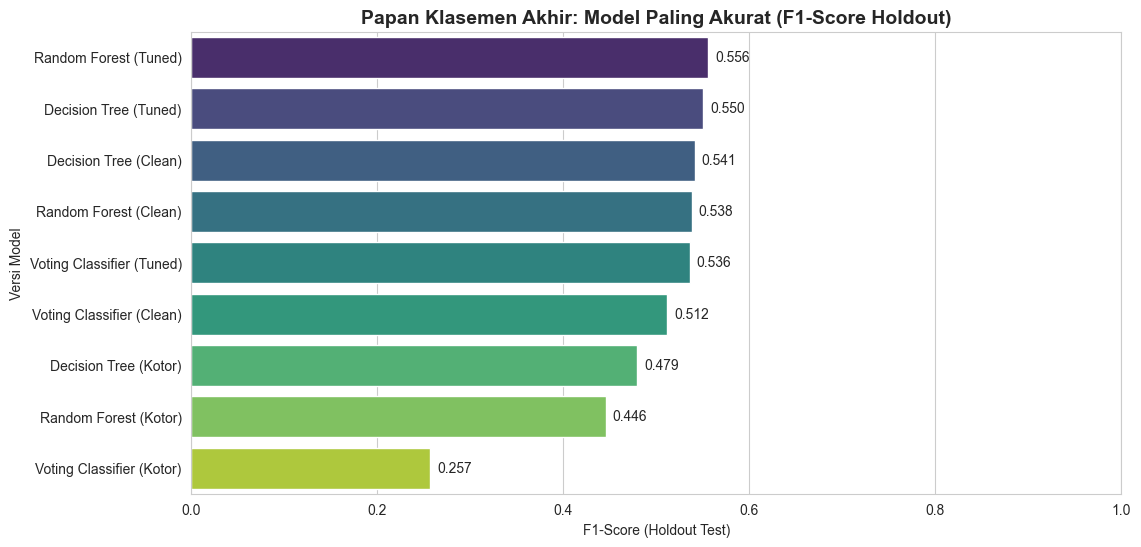

In [61]:
# 59. Penentuan Juara: Klasemen Akhir Berdasarkan F1-Score

# Mengurutkan murni berdasarkan F1-Score (Holdout Test) dari tertinggi ke terendah
df_juara = df_grand_komparasi.sort_values(by='F1-Score', ascending=False)

print("=== KLASEMEN AKHIR (Berdasarkan F1-Score Murni) ===")
display(df_juara)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_juara.reset_index(),
    y='index',  
    x='F1-Score', # <--- PERBAIKAN: Memanggil kolom F1-Score biasa
    palette='viridis'
)
plt.title('Papan Klasemen Akhir: Model Paling Akurat (F1-Score Holdout)', fontweight='bold', fontsize=14)
plt.xlabel('F1-Score (Holdout Test)')
plt.ylabel('Versi Model')
plt.xlim(0, 1)

# Menambahkan angka presisi di ujung setiap batang grafik
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.show()


## SAVE FILE MODEL

In [ ]:
# 61. Import Library untuk Ekspor (Deployment Preparation)

import joblib
import os

print("✅ Library joblib siap digunakan untuk mengemas (export) model!")


✅ Library joblib siap digunakan untuk mengemas (export) model!


In [ ]:
# 62. Ekspor Model Terbaik (Juara 1)

# Berdasarkan hasil klasemen, Decision Tree (Tuned) adalah model paling optimal
# Kita akan menyimpannya ke dalam file biner agar tidak perlu di-training ulang dari awal
nama_file_model = 'model_churn_terbaik.pkl'
joblib.dump(best_dt, nama_file_model)

print(f"✅ Model Decision Tree (Tuned) berhasil dikemas secara permanen menjadi: '{nama_file_model}'")

✅ Model Decision Tree (Tuned) berhasil dikemas secara permanen menjadi: 'model_churn_terbaik.pkl'


In [ ]:
# 63. Ekspor Komponen Pendukung (Scaler, Encoder, dan Daftar Fitur VIP)

# PENTING: Saat aplikasi web (Streamlit) menerima data baru dari user, 
# data tersebut MASIH MENTAH! Kita butuh alat-alat ini untuk mengubahnya menjadi VIP.

# 1. Menyimpan StandardScaler (Alat peramping skala dari Cell 32)
joblib.dump(scaler, 'scaler_churn.pkl')
print("✅ StandardScaler berhasil disimpan!")

# 2. Menyimpan kamus LabelEncoder (Alat penerjemah teks ke angka dari Cell 31)
joblib.dump(label_encoders, 'encoder_churn.pkl')
print("✅ Label Encoders (kamus penerjemah) berhasil disimpan!")

# 3. Menyimpan daftar nama fitur VIP (Agar urutan kolom saat input di web tidak tertukar)
joblib.dump(fitur_terpilih, 'fitur_vip_churn.pkl')
print("✅ Daftar Fitur VIP berhasil disimpan!")


✅ StandardScaler berhasil disimpan!
✅ Label Encoders (kamus penerjemah) berhasil disimpan!
✅ Daftar Fitur VIP berhasil disimpan!
